# Let's get going and preprocess some data 😏
 إنسان الي كاتب والله 😂

In [1]:
import tensorflow as tf
import keras
print("TF:", tf.__version__)
print("Keras:", keras.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TF: 2.19.0
Keras: 3.13.2
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Starter Code (Provided by the supervisor)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import layers, models, callbacks
from keras.datasets import cifar10
from keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import time

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# CIFAR-10 Class Names
CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

# Load Data
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

# Fixed Split: 40,000 train / 10,000 val / 10,000 test
x_train = x_train_full[:40000].astype('float32')
y_train = y_train_full[:40000]
x_val   = x_train_full[40000:].astype('float32')
y_val   = y_train_full[40000:]
x_test  = x_test.astype('float32')

print(f"Train: {x_train.shape} | Val: {x_val.shape} | Test: {x_test.shape}")
print(f"Pixel range: [{x_train.min()}, {x_train.max()}]")
print(f"Image shape: {x_train[0].shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 68s 0us/step
Train: (40000, 32, 32, 3) | Val: (10000, 32, 32, 3) | Test: (10000, 32, 32, 3)
Pixel range: [0.0, 255.0]
Image shape: (32, 32, 3)


## Helping Functions (also proivded by the supervisor) ربنا يخليهولنا

In [3]:
def train_and_evaluate(model, x_tr, y_tr, x_v, y_v, x_te, y_te,
                       epochs=20, batch_size=128, extra_callbacks=None):
    cb = extra_callbacks if extra_callbacks else []
    start = time.time()
    history = model.fit(x_tr, to_categorical(y_tr, 10),
                        validation_data=(x_v, to_categorical(y_v, 10)),
                        epochs=epochs, batch_size=batch_size,
                        callbacks=cb, verbose=0)
    elapsed = time.time() - start
    test_loss, test_acc = model.evaluate(x_te, to_categorical(y_te, 10), verbose=0)
    print(f"Test Acc: {test_acc:.4f} | Test Loss: {test_loss:.4f} | Time: {elapsed:.1f}s")
    return history, test_acc, test_loss, elapsed

def plot_curves(histories, labels, metric='val_accuracy', title='', ylabel=''):
    plt.figure(figsize=(10, 6))
    for h, lbl in zip(histories, labels):
        plt.plot(h.history[metric], label=lbl)
    plt.xlabel('Epoch')
    plt.ylabel(ylabel if ylabel else metric)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

## The actual data preprocessing (Finally 🥱)
I'm the one who wrote the code, but since I didn't know a lot about tensorflow, I asked GPT-5 mini about how to write it first. (and then Gemini Pro 3.1 because mini 5 decided just decided suddenly to blank out)

In [4]:
def build_baseline_cnn(input_shape = (32, 32, 3), num_classes = 10):
    """
    builds a 4-layer CNN model using ReLU as an activatiation function

    Arguments:
        input_shape -- shape of the data "length, width, color channels (RGB)" (tuple)
        num_classes -- number of classes (int)

    Returns:
        Fully constructed CNN model ()
    """

    m = models.Sequential([
        layers.Conv2D(32, (3,3), activation = 'relu', padding = 'same', input_shape = input_shape),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64, (3,3), activation = 'relu', padding = 'same'),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(128, activation = 'relu'),
        layers.Dense(num_classes, activation = 'softmax'),
    ])

    m.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
    return m

## Preprocessing helper functions

In [5]:
def preprocess_none(x):
    return x.astype('float32')

def preprocess_minmax(x):
    return x.astype('float32') / 255.0

def compute_train_stats(x_train):
    x = x_train.astype('float32')
    mean = x.mean(axis = (0,1,2))
    std = x.std(axis = (0,1,2))
    return mean, std

def preprocess_standardize(x, mean, std):
    return (x.astype('float32') - mean) / std

## Let's try and check if everything runs well or not 🙃

In [6]:
# Let's start by building the model
model = build_baseline_cnn()

# Then let's create the different variations of data with different types of preprocessing for the different expirments.
x_exp_a = preprocess_none(x_train) # Features as they are with nothing changed
x_exp_b = preprocess_minmax(x_train) # Normalized features.
train_mean, train_std = compute_train_stats(x_train) # X_train mean and standard deviation.
x_exp_c = preprocess_standardize(x_train, train_mean, train_std) # X_train standardized per channel.

# Time to try and train the actual model that we've built
history_exp_a, test_acc_exp_a, test_loss_exp_a, elapsed_exp_a = train_and_evaluate(model, x_exp_a, y_train, x_val, y_val, x_test, y_test)
history_exp_b, test_acc_exp_b, test_loss_exp_b, elapsed_exp_b = train_and_evaluate(model, x_exp_b, y_train, x_val, y_val, x_test, y_test)
history_exp_c, test_acc_exp_c, test_loss_exp_c, elapsed_exp_c = train_and_evaluate(model, x_exp_c, y_train, x_val, y_val, x_test, y_test)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Acc: 0.5421 | Test Loss: 2.9059 | Time: 47.3s
Test Acc: 0.4896 | Test Loss: 254.3501 | Time: 41.6s
Test Acc: 0.4152 | Test Loss: 318.5395 | Time: 40.9s


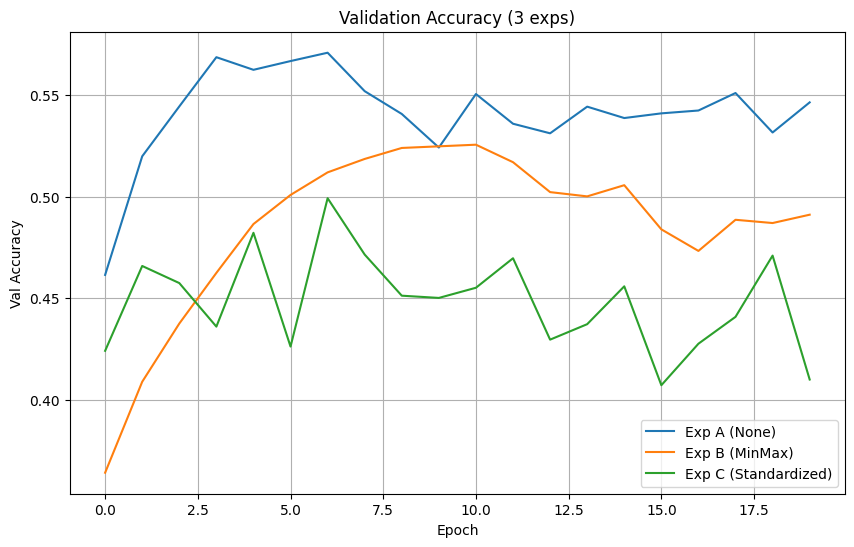

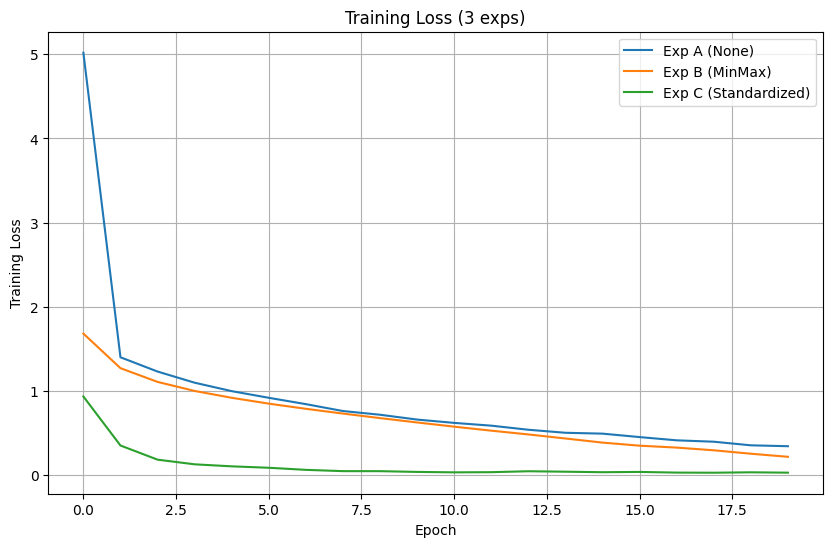

In [7]:
# Now let's gather the histories together to plot them out.
histories = [history_exp_a, history_exp_b, history_exp_c]
labels = ['Exp A (None)','Exp B (MinMax)','Exp C (Standardized)']

# Finally the plotting step 🤩
plot_curves(histories, labels, metric = 'val_accuracy', title = "Validation Accuracy (3 exps)", ylabel = "Val Accuracy")
plot_curves(histories, labels, metric = 'loss', title = "Training Loss (3 exps)", ylabel = "Training Loss")


# **Task 2**
> standardized data for ALL experiments in this task

## *2A. Filter Count Comparison*

### Build model

In [8]:
def build_model(input_shape = (32, 32, 3), num_classes = 10, f1 = 8, f2 = 8, f3 = 16, f4 = 16):
    """
    Build different models with different number of filters

    Args:
        input_shape (tuple, optional): shape of the input. Defaults to (32, 32, 3).
        num_classes (int, optional): number of classes. Defaults to 10.
        f1 (int, optional): # of filter or 1st conv. Defaults to 8.
        f2 (int, optional): # of filter or 2nd conv. Defaults to 8.
        f3 (int, optional): # of filter or 3rd conv. Defaults to 16.
        f4 (int, optional): # of filter or 4th conv. Defaults to 16.

    Returns:
        model: model with desired number of filters for each conolution layer
    """

    m = models.Sequential([
        layers.Conv2D(f1, (3, 3), activation= 'relu', padding= 'same', input_shape= input_shape),
        layers.Conv2D(f2, (3, 3), activation= 'relu', padding= 'same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(f3, (3, 3), activation= 'relu', padding= 'same'),
        layers.Conv2D(f4, (3, 3), activation= 'relu', padding= 'same'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(256, activation= 'relu'),
        layers.Dense(10, activation= 'softmax')
    ])

    m.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
    return m

In [9]:
x_standarized = x_exp_c.copy()

f_1 = [8, 32, 64]
f_2 = [8, 32, 64]
f_3 = [16, 64, 128]
f_4 = [16, 64, 128]

ms = {
    0 : 'Small Model',
    1 : 'Medium Model',
    2 : 'Large Model'
}

histories_T2_2A = []

for i in range(0, 3):
    model = build_model(f1= f_1[i], f2= f_2[i], f3= f_3[i], f4= f_4[i])

    print(f"=======================",
          f"      Summarry of {ms[i]}      ",
          f"======================="
        )
    history, test_acc, test_loss, elapsed = train_and_evaluate(model, x_standarized, y_train, x_val, y_val, x_test, y_test)
    model.summary()

    histories_T2_2A.append(history)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


=======================       Summarry of Small Model       =======================
Test Acc: 0.4312 | Test Loss: 224.7708 | Time: 41.6s


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 8)      │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 807,800 (3.08 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,080,416 (27.01 MB)

 Trainable params: 2,360,138 (9.00 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,720,278 (18.01 MB)

### Plot

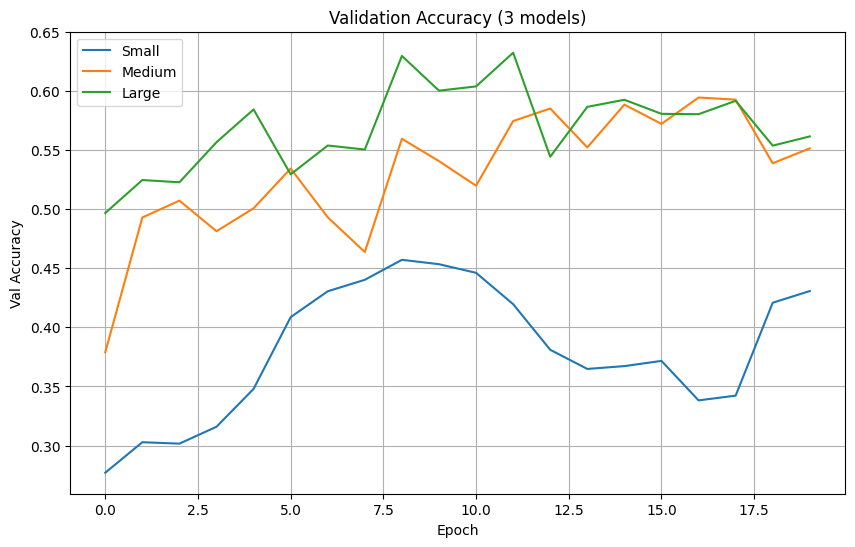

In [10]:
labels_task2_2A = ['Small', 'Medium', 'Large']

plot_curves(histories_T2_2A, labels_task2_2A, metric = 'val_accuracy', title = "Validation Accuracy (3 models)", ylabel = "Val Accuracy")

## *2C. Network Depth Comparison*

### Shallow Depth

In [11]:
shallow_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding= 'same', input_shape= (32, 32, 3)),
    layers.Conv2D(32, (3, 3), activation= 'relu', padding= 'same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(32, (3, 3), activation= 'relu', padding= 'same'),
    layers.Conv2D(32, (3, 3), activation= 'relu', padding= 'same'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(256, activation= 'relu'),
    layers.Dense(10, activation= 'softmax')
])

shallow_model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])

shallow_history, shallow_test_acc, shallow_test_loss, shallow_elapsed = \
            train_and_evaluate(shallow_model, x_standarized, y_train, x_val, y_val, x_test, y_test)


Test Acc: 0.5235 | Test Loss: 206.0609 | Time: 68.1s


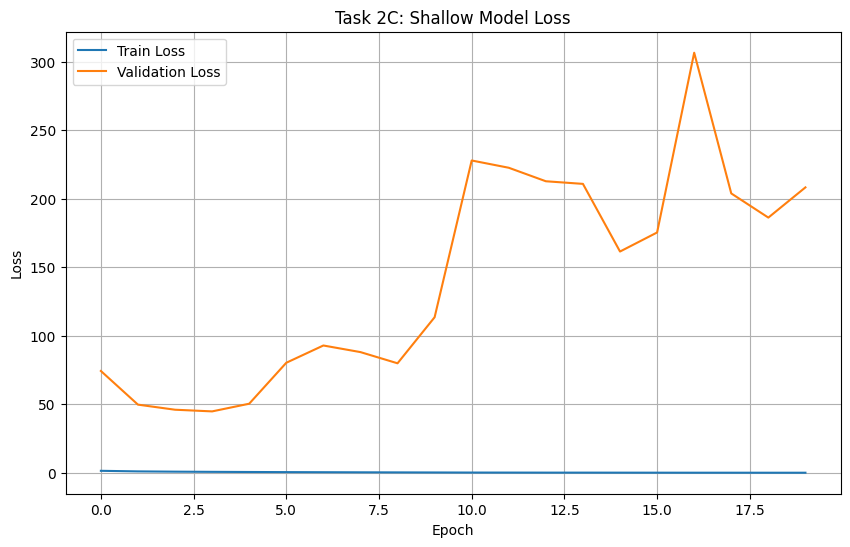

In [12]:
# Plot Training and Validation Loss for the Shallow Model
plt.figure(figsize=(10, 6))
plt.plot(shallow_history.history['loss'], label='Train Loss')
plt.plot(shallow_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Task 2C: Shallow Model Loss')
plt.legend()
plt.grid(True)
plt.show()

### Medium Depth

In [13]:
medium_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding= 'same', input_shape= (32, 32, 3)),
    layers.Conv2D(32, (3, 3), activation= 'relu', padding= 'same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(32, (3, 3), activation= 'relu', padding= 'same'),
    layers.Conv2D(32, (3, 3), activation= 'relu', padding= 'same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(32, (3, 3), activation= 'relu', padding= 'same'),
    layers.Conv2D(32, (3, 3), activation= 'relu', padding= 'same'),
    layers.GlobalAveragePooling2D(),

    layers.Flatten(),
    layers.Dense(256, activation= 'relu'),
    layers.Dense(10, activation= 'softmax')
])

medium_model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])

medium_history, medium_test_acc, medium_test_loss, medium_elapsed = \
            train_and_evaluate(medium_model, x_standarized, y_train, x_val, y_val, x_test, y_test)


Test Acc: 0.5465 | Test Loss: 48.8952 | Time: 74.8s


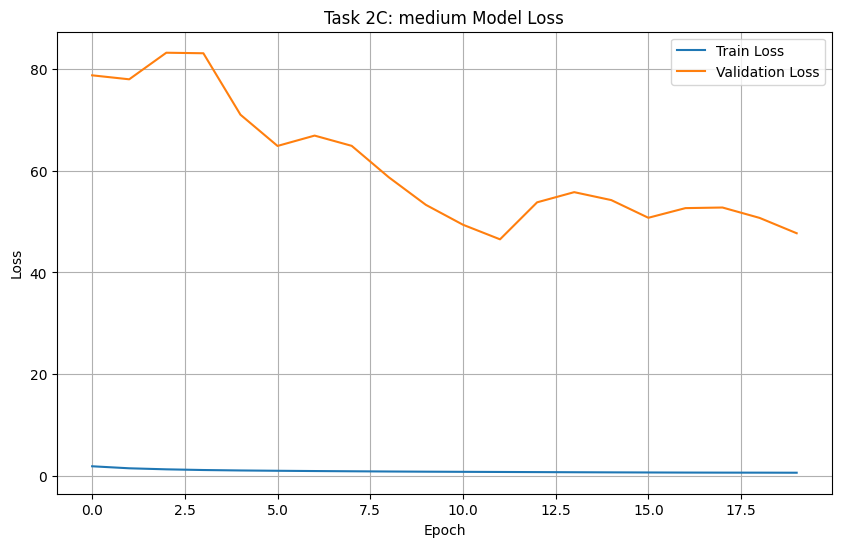

In [14]:
# Plot Training and Validation Loss for the medium Model
plt.figure(figsize=(10, 6))
plt.plot(medium_history.history['loss'], label='Train Loss')
plt.plot(medium_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Task 2C: medium Model Loss')
plt.legend()
plt.grid(True)
plt.show()

### Deep Depth

In [15]:
deep_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding= 'same', input_shape= (32, 32, 3)),
    layers.Conv2D(32, (3, 3), activation= 'relu', padding= 'same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(32, (3, 3), activation= 'relu', padding= 'same'),
    layers.Conv2D(32, (3, 3), activation= 'relu', padding= 'same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(32, (3, 3), activation= 'relu', padding= 'same'),
    layers.Conv2D(32, (3, 3), activation= 'relu', padding= 'same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(32, (3, 3), activation= 'relu', padding= 'same'),
    layers.Conv2D(32, (3, 3), activation= 'relu', padding= 'same'),
    layers.GlobalAveragePooling2D(),

    layers.Flatten(),
    layers.Dense(256, activation= 'relu'),
    layers.Dense(10, activation= 'softmax')
])

deep_model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])

deep_history, deep_test_acc, deep_test_loss, deep_elapsed = \
            train_and_evaluate(deep_model, x_standarized, y_train, x_val, y_val, x_test, y_test)


Test Acc: 0.4387 | Test Loss: 69.0553 | Time: 74.0s


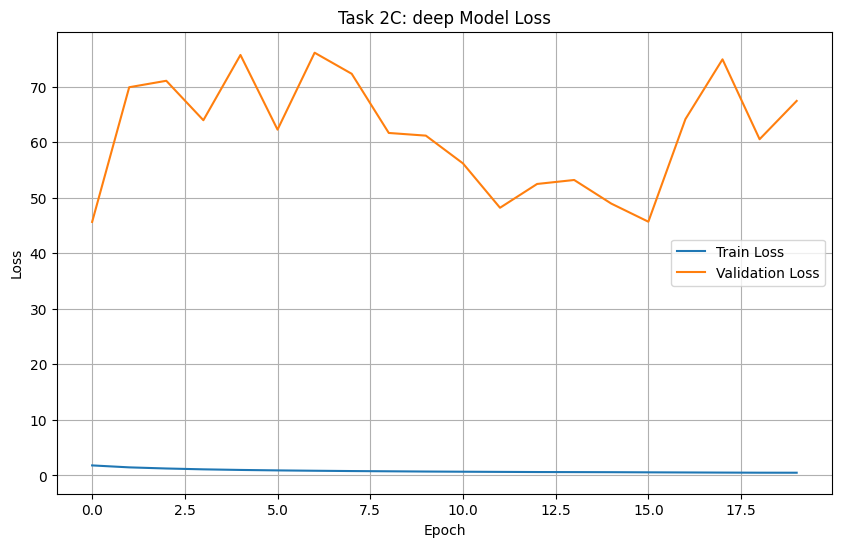

In [16]:
# Plot Training and Validation Loss for the deep Model
plt.figure(figsize=(10, 6))
plt.plot(deep_history.history['loss'], label='Train Loss')
plt.plot(deep_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Task 2C: deep Model Loss')
plt.legend()
plt.grid(True)
plt.show()

# Task 4

## *4A. Same Learning Rate — 5 Optimizers*

In [23]:
def build_medium_model(opt_object):

    m = models.Sequential([
        layers.Conv2D(32, (3, 3), activation= 'relu', padding= 'same', input_shape= (32, 32, 3)),
        layers.Conv2D(32, (3, 3), activation= 'relu', padding= 'same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation= 'relu', padding= 'same'),
        layers.Conv2D(64, (3, 3), activation= 'relu', padding= 'same'),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(256, activation= 'relu'),
        layers.Dense(10, activation= 'softmax')
    ])

    m.compile(optimizer = opt_object, loss = 'categorical_crossentropy', metrics = ['accuracy'])

    return m

In [24]:
optimizers = ['SGD', 'RMSprop', 'Adam', 'Adagrad', 'Nadam']

In [25]:
optimizers_history = {}
lr = 0.001

for opt_name in optimizers:
    print(f"--- Training Medium Model with Optimizer: {opt_name} ---")

    if opt_name == 'SGD':
        opt_object = keras.optimizers.SGD(learning_rate=lr)
    elif opt_name == 'RMSprop':
        opt_object = keras.optimizers.RMSprop(learning_rate=lr)
    elif opt_name == 'Adam':
        opt_object = keras.optimizers.Adam(learning_rate=lr)
    elif opt_name == 'Adagrad':
        opt_object = keras.optimizers.Adagrad(learning_rate=lr)
    elif opt_name == 'Nadam':
        opt_object = keras.optimizers.Nadam(learning_rate=lr)

    optimizer_test_model = build_medium_model(opt_object)

    history, test_acc, test_loss, elapsed = train_and_evaluate(
        optimizer_test_model,
        x_standarized, y_train,
        x_val, y_val,
        x_test, y_test,
        epochs= 30
    )

    optimizers_history[opt_name] = history

print("All optimizers trained successfully!")

--- Training Medium Model with Optimizer: SGD ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Acc: 0.2436 | Test Loss: 135.6042 | Time: 115.6s
--- Training Medium Model with Optimizer: RMSprop ---
Test Acc: 0.5452 | Test Loss: 275.0053 | Time: 115.3s
--- Training Medium Model with Optimizer: Adam ---
Test Acc: 0.5592 | Test Loss: 194.6261 | Time: 112.7s
--- Training Medium Model with Optimizer: Adagrad ---
Test Acc: 0.2965 | Test Loss: 131.4577 | Time: 113.3s
--- Training Medium Model with Optimizer: Nadam ---
Test Acc: 0.5417 | Test Loss: 217.1037 | Time: 115.9s
All optimizers trained successfully!


### Plot

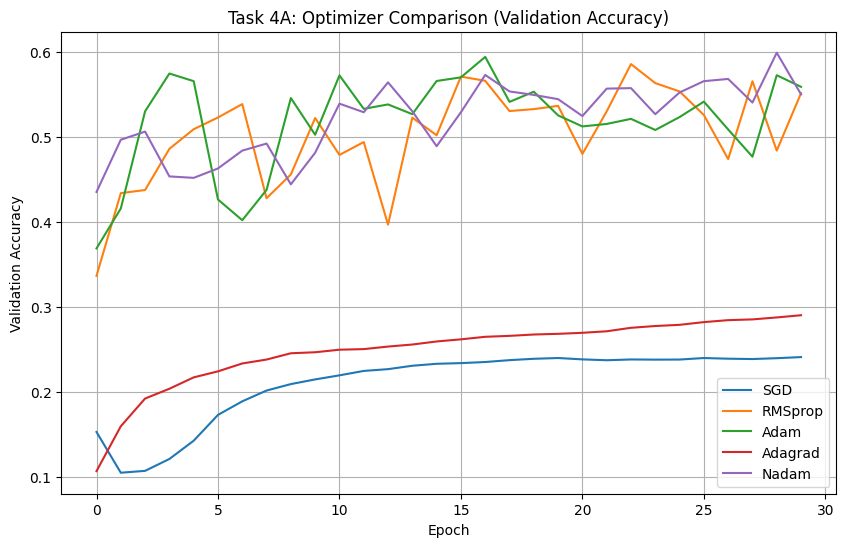

In [26]:
histories_T4_4A = list(optimizers_history.values())
labels_T4_4A = list(optimizers_history.keys())

plot_curves(
    histories= histories_T4_4A,
    labels= labels_T4_4A,
    metric= 'val_accuracy',
    title= 'Task 4A: Optimizer Comparison (Validation Accuracy)',
    ylabel= 'Validation Accuracy'
)

## *4B. Learning Rate Sensitivity — Adam*

In [29]:
learning_rates = {'LR1': 0.0001, 'LR2': 0.001, 'LR3': 0.01}
lr_history = {}

for lr, lr_value in learning_rates.items():
    print(f"--- Training Medium Model with lr: {lr_value} ---")

    if lr == 'LR1':
        opt_object = keras.optimizers.Adam(learning_rate=0.0001)
    elif lr == 'LR2':
        opt_object = keras.optimizers.Adam(learning_rate=0.001)
    elif lr == 'LR3':
        opt_object = keras.optimizers.Adam(learning_rate=0.01)

    lr_test_model = build_medium_model(opt_object)

    history, test_acc, test_loss, elapsed = train_and_evaluate(
        lr_test_model,
        x_standarized, y_train,
        x_val, y_val,
        x_test, y_test,
        epochs= 30
    )

    lr_history[lr] = history

print("All learning rates tested successfully!")

--- Training Medium Model with lr: 0.0001 ---
Test Acc: 0.4156 | Test Loss: 127.7235 | Time: 116.4s
--- Training Medium Model with lr: 0.001 ---
Test Acc: 0.4960 | Test Loss: 291.0417 | Time: 113.4s
--- Training Medium Model with lr: 0.01 ---
Test Acc: 0.2604 | Test Loss: 194.3792 | Time: 108.0s
All learning rates tested successfully!


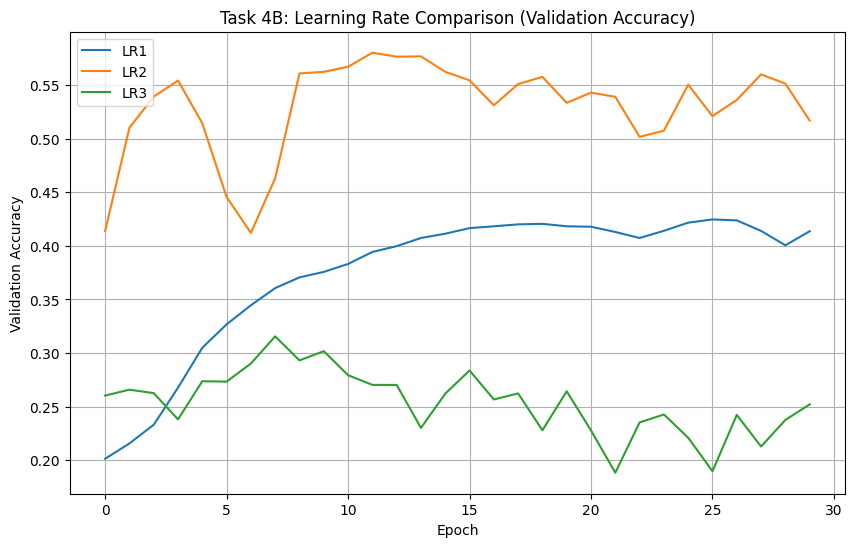

In [30]:
histories_T4_4B = list(lr_history.values())
labels_T4_4B = list(lr_history.keys())

plot_curves(
    histories= histories_T4_4B,
    labels= labels_T4_4B,
    metric= 'val_accuracy',
    title= 'Task 4B: Learning Rate Comparison (Validation Accuracy)',
    ylabel= 'Validation Accuracy'
)